<a href="https://colab.research.google.com/github/anwaruddin1/Bioinformatics-Workshop/blob/main/02_scRNAseq_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Marker Analysis and Cell Annotation

In [1]:
#untar("R_library.tar.gz")
untar("R_library_July12_26.tar.gz")
#list.files("library")

In [2]:
# change the R library directory into './library'
.libPaths("library")

In [3]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [4]:
obj40 <- readRDS(file = "obj_combined.integrated_40res.rds")
obj40

An object of class Seurat 
44779 features across 1868 samples within 3 assays 
Active assay: integrated (3000 features, 3000 variable features)
 2 layers present: data, scale.data
 2 other assays present: RNA, SCT
 3 dimensional reductions calculated: pca, umap, tsne

In [5]:
DefaultAssay(obj40) <- "SCT"

## Find markers for every cluster compared to all remaining cells, report only the positive ones
Prior to performing differential expression, we first run PrepSCTFindMarkers, which ensures that the fixed value is set properly.

In [6]:
obj40 <- PrepSCTFindMarkers(obj40)

Found 2 SCT models. Recorrecting SCT counts using minimum median counts: 2045.95476398253



In [7]:
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.markers <- FindAllMarkers(obj40, only.pos = TRUE, min.pct = 0.30, logfc.threshold = 0.30, recorrect_umi = FALSE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7



## Now lets generate heatmap and dotplot for each of the clusters.

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster0.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: CDKN2A, KCNB2, NRCAM, FDCSP, ENSG00000248515, SFRP1, NTRK2, CALML5, GNGT1”


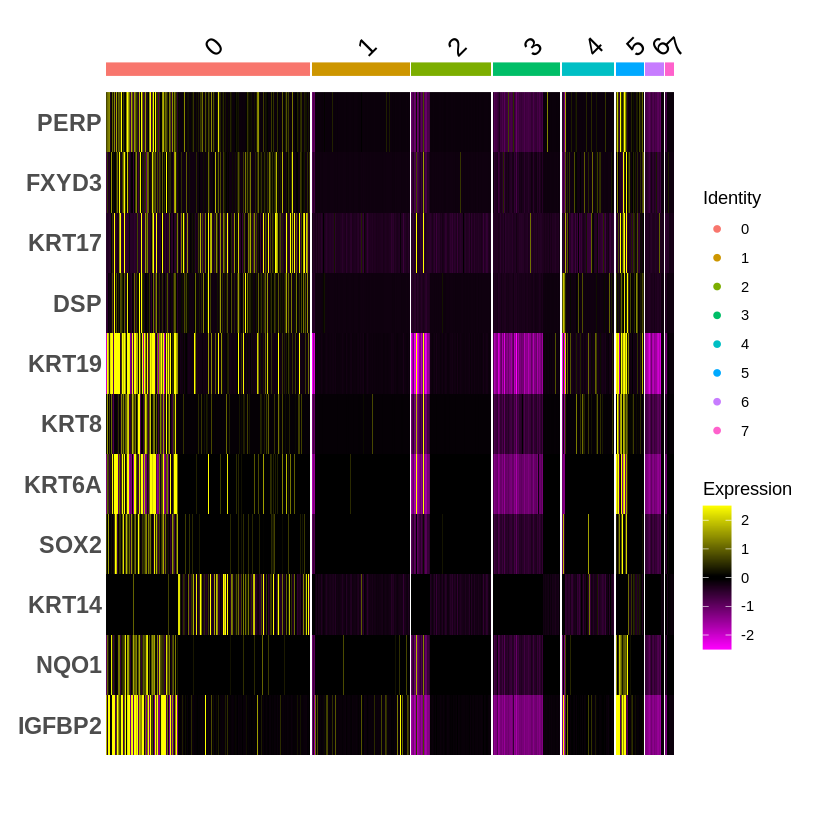

In [8]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_0.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster0.markers <- obj40.markers %>% filter(cluster==0) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster0.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

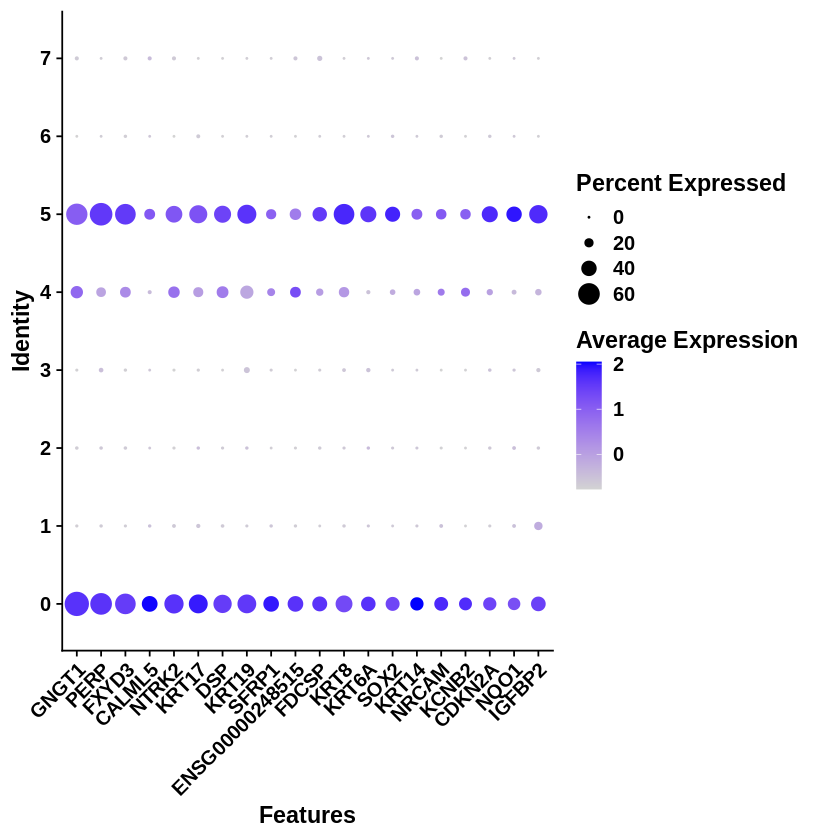

In [9]:

## Dotplot for Cluster_0
obj40.cluster0.markers$gene %>% write.table("obj40.cluster0.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster0.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster1.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: PRSS23, PCOLCE, MMP2”


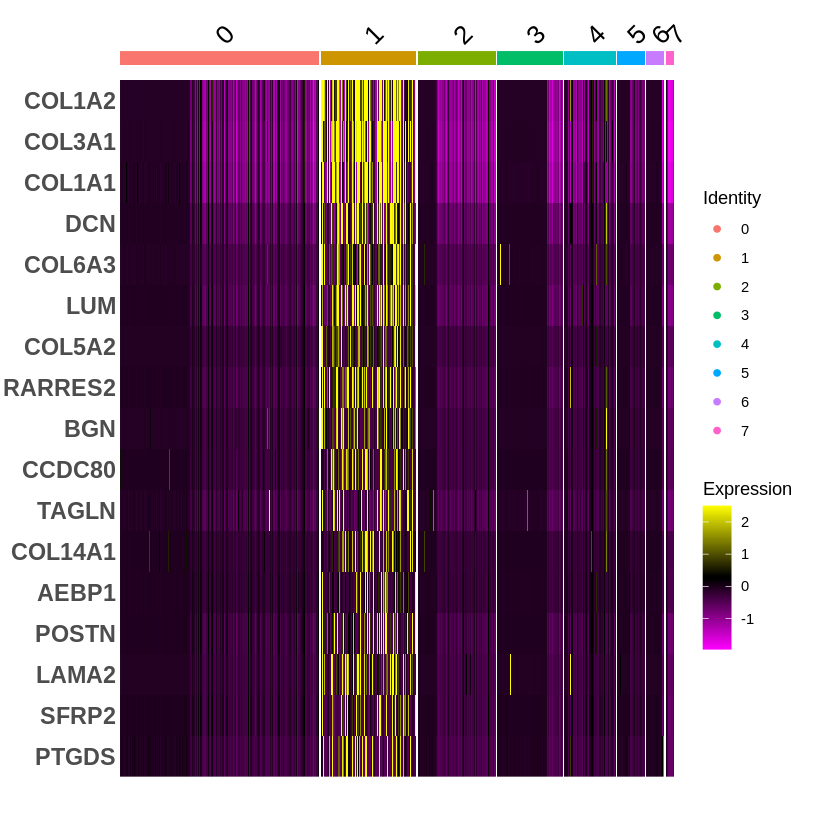

In [10]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_1.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster1.markers <- obj40.markers %>% filter(cluster==1) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster1.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))


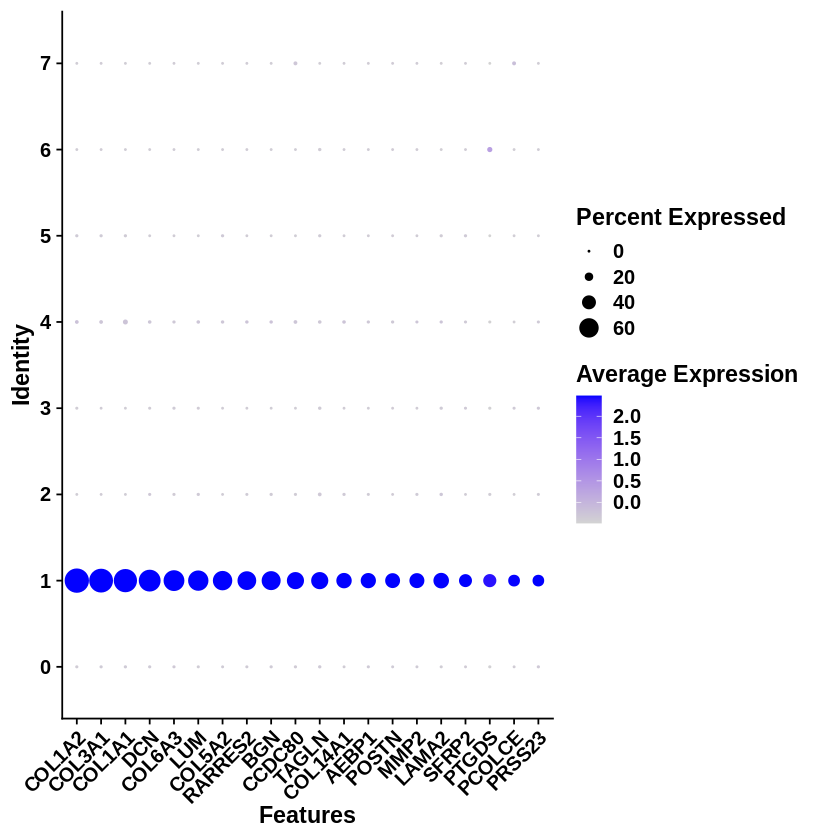

In [11]:
## Dotplot for Cluster_1
obj40.cluster1.markers$gene %>% write.table("obj40.cluster1.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster1.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster2.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: SPI1, MS4A4A, FCGR2A, CLEC7A, CD68”


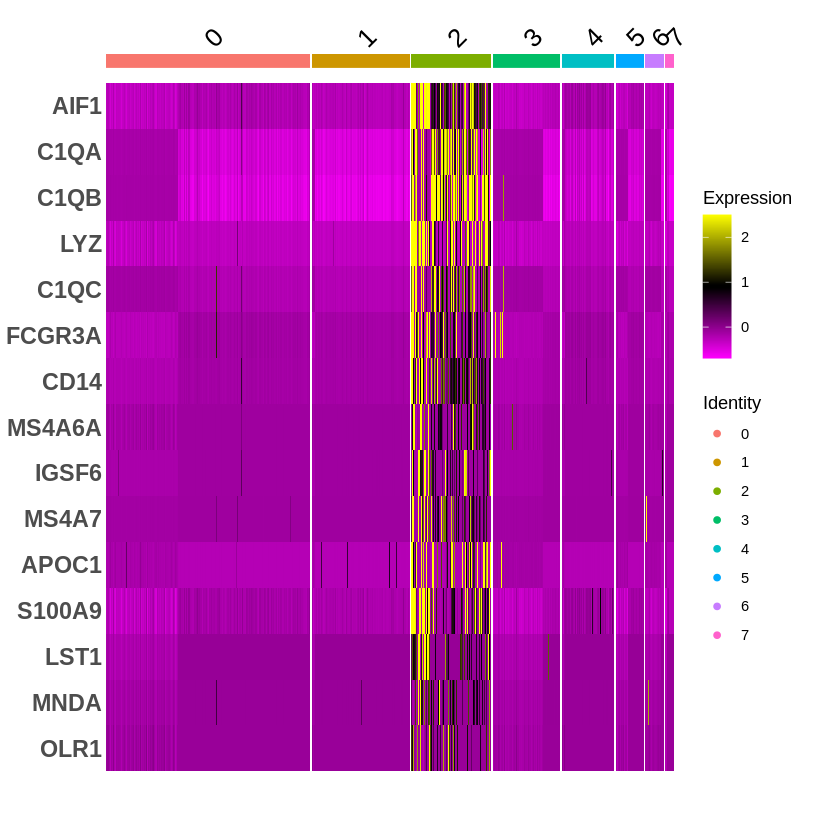

In [12]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_2.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster2.markers <- obj40.markers %>% filter(cluster==2) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster2.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

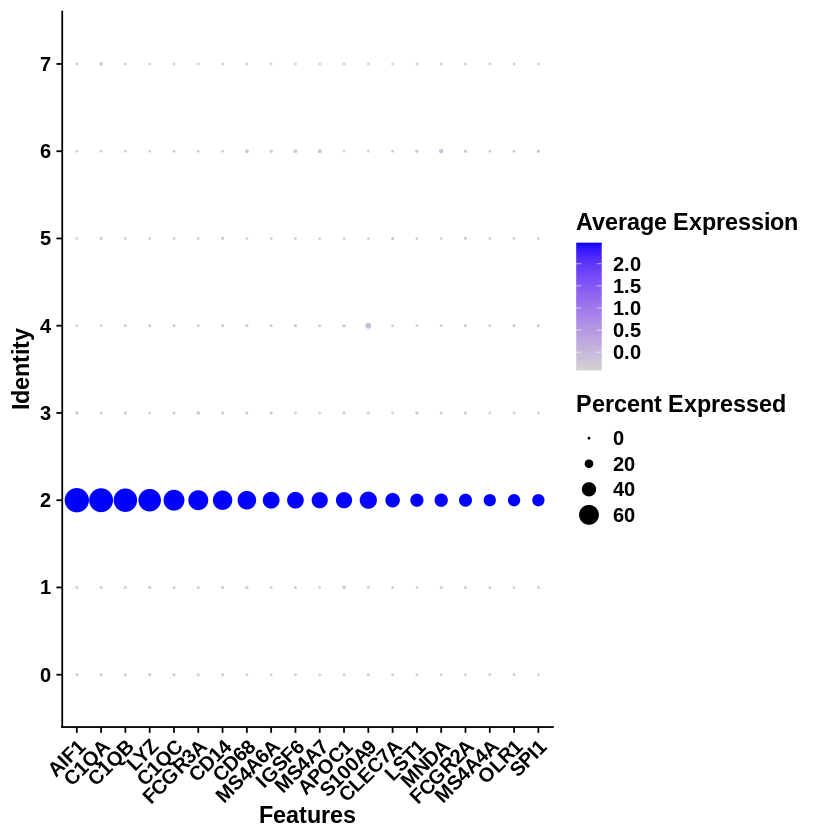

In [13]:
## Dotplot for Cluster_2
obj40.cluster2.markers$gene %>% write.table("obj40.cluster2.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster2.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

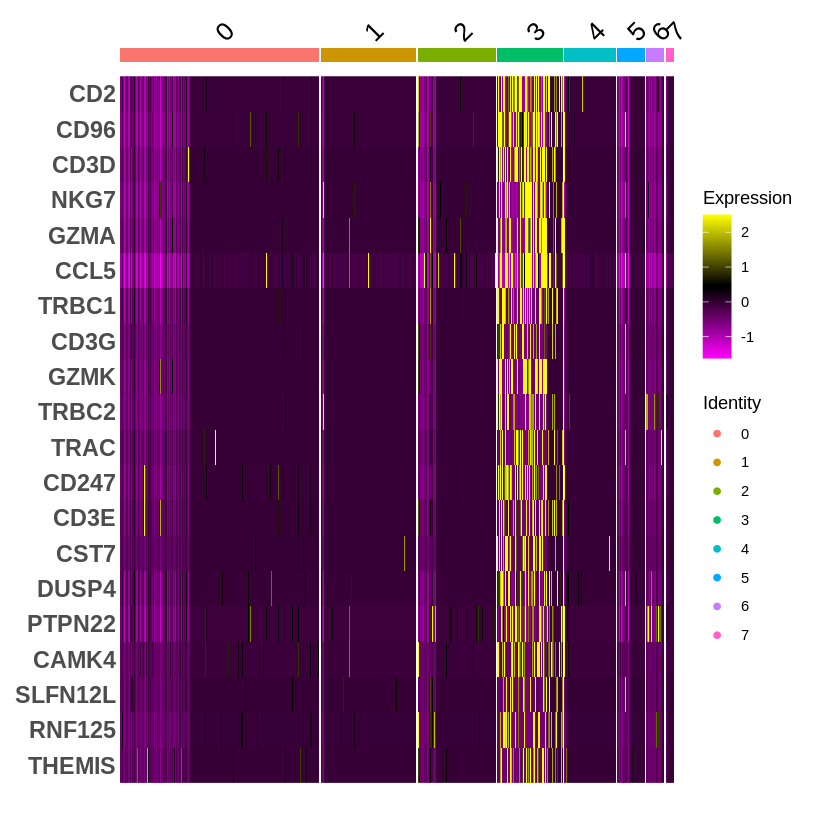

In [14]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_3.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster3.markers <- obj40.markers %>% filter(cluster==3) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster3.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

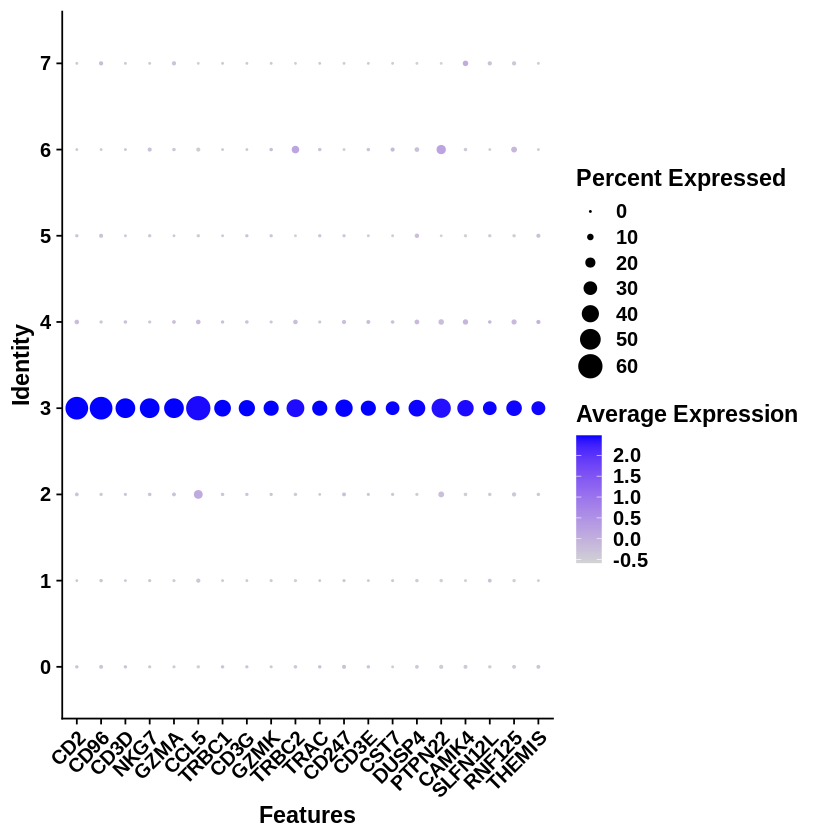

In [15]:
## Dotplot for Cluster_3
obj40.cluster3.markers$gene %>% write.table("obj40.cluster3.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster3.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster4.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: PTPN13, TDRP, CYB5A, NFIA, PPP1R13B, ERRFI1, EPB41L5, GCNT2, CDH1, MYO6, MAGI3, MECOM, LMO7, NEDD4L, SFTPB”


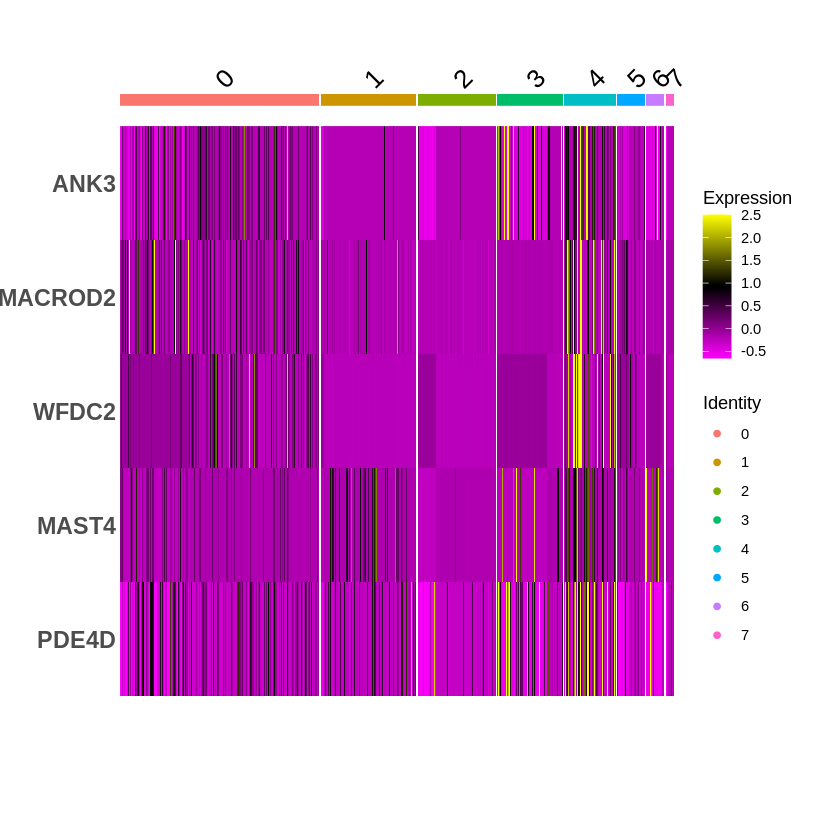

In [16]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_4.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster4.markers <- obj40.markers %>% filter(cluster==4) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster4.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

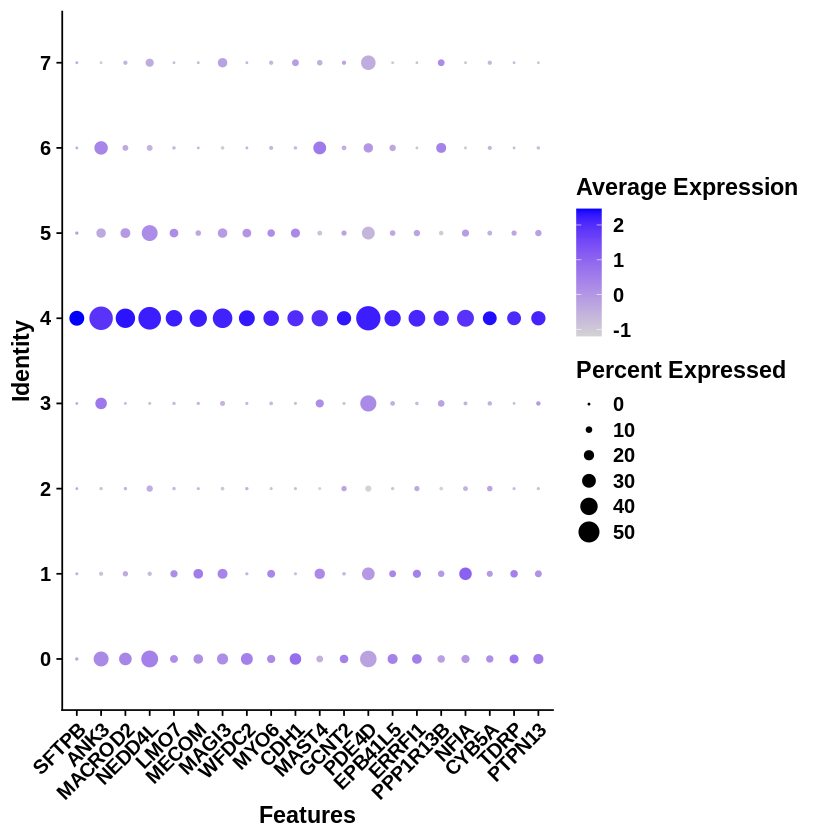

In [17]:
## Dotplot for Cluster_4
obj40.cluster4.markers$gene %>% write.table("obj40.cluster4.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster4.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster5.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: H1-1, TMEM106C, ECT2, CCNB1, PTTG1, CENPE, MAD2L1, NUSAP1, CKS1B, ASPM, GTSE1, MKI67, UBE2C, TPX2”


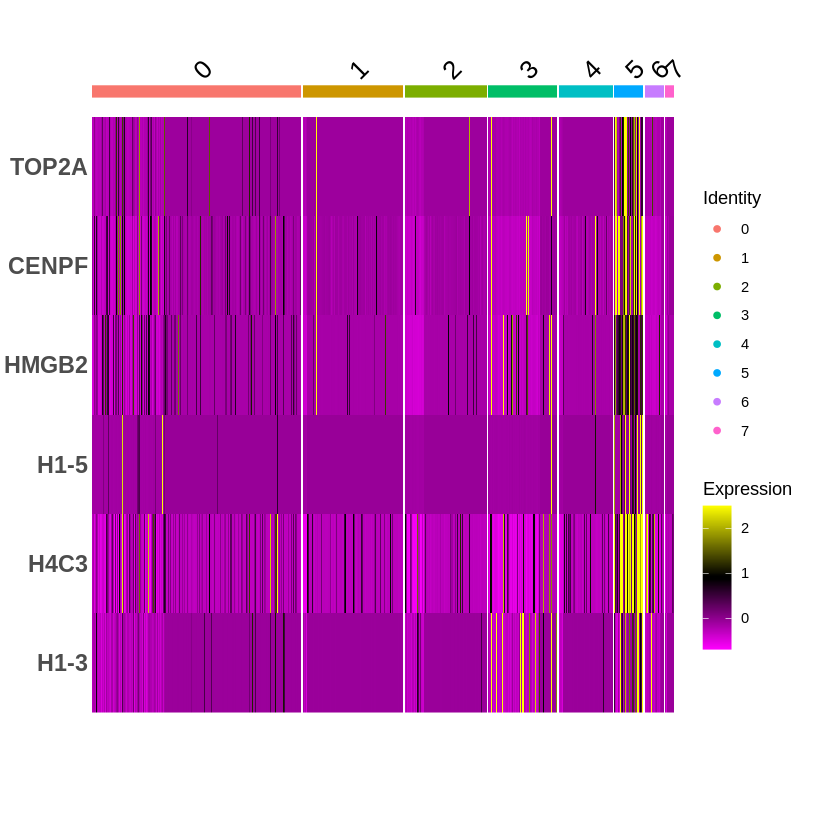

In [18]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_5.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster5.markers <- obj40.markers %>% filter(cluster==5) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster5.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

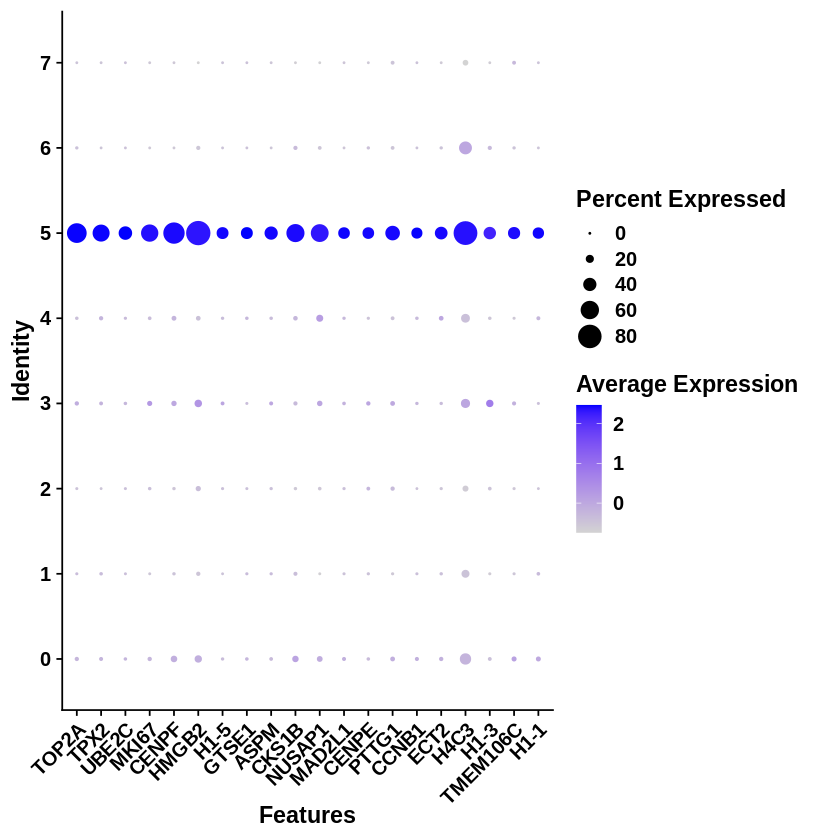

In [19]:
## Dotplot for Cluster_5
obj40.cluster5.markers$gene %>% write.table("obj40.cluster5.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster5.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster6.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: TNFRSF13C, CD79B, PAX5, MS4A1”


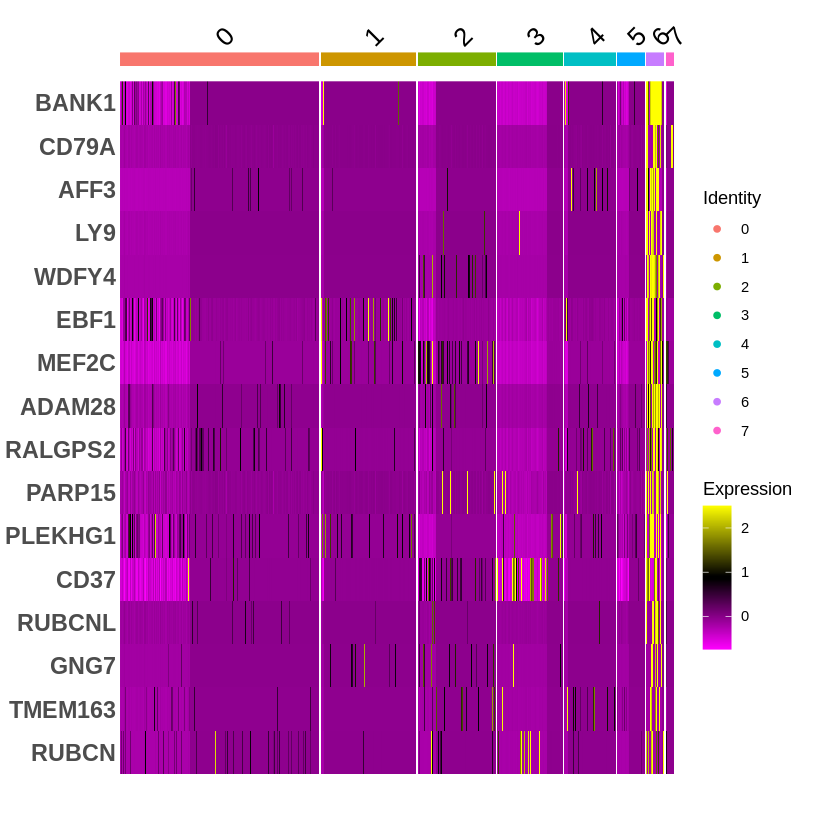

In [20]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_6.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster6.markers <- obj40.markers %>% filter(cluster==6) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster6.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

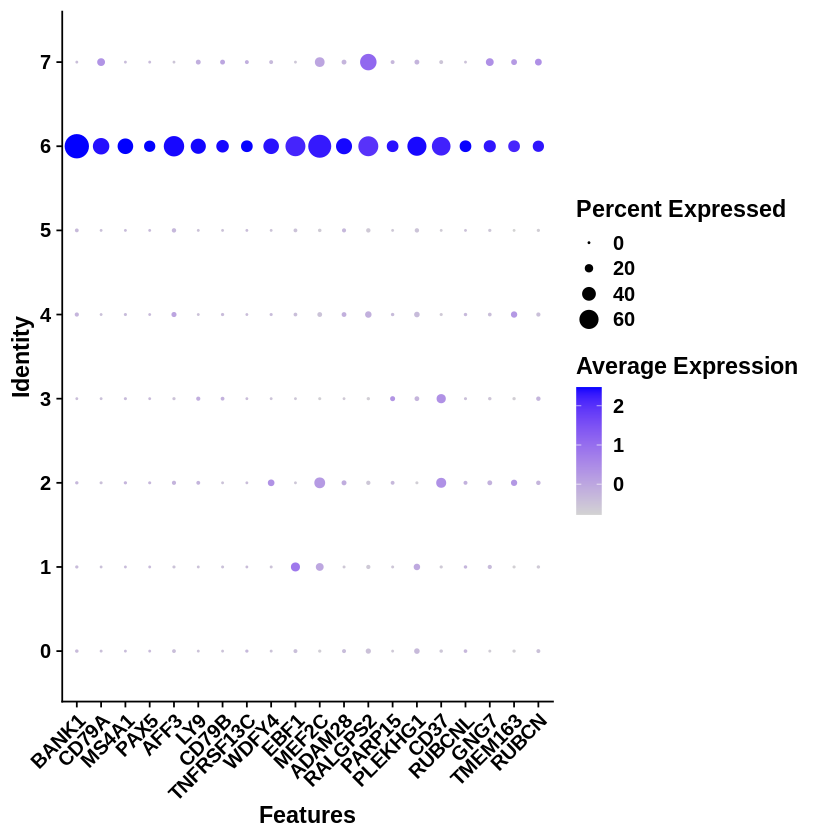

In [21]:
## Dotplot for Cluster_6
obj40.cluster6.markers$gene %>% write.table("obj40.cluster6.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster6.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

Warning message in DoHeatmap(obj40, features = as.character(c(obj40.cluster7.markers$gene)), :
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: TMEM107, BCAR3, SEC11C, TXNDC5, FKBP11, ANKRD36BP2, FCRL5, IGHG2, IGHG3, IGHG4”


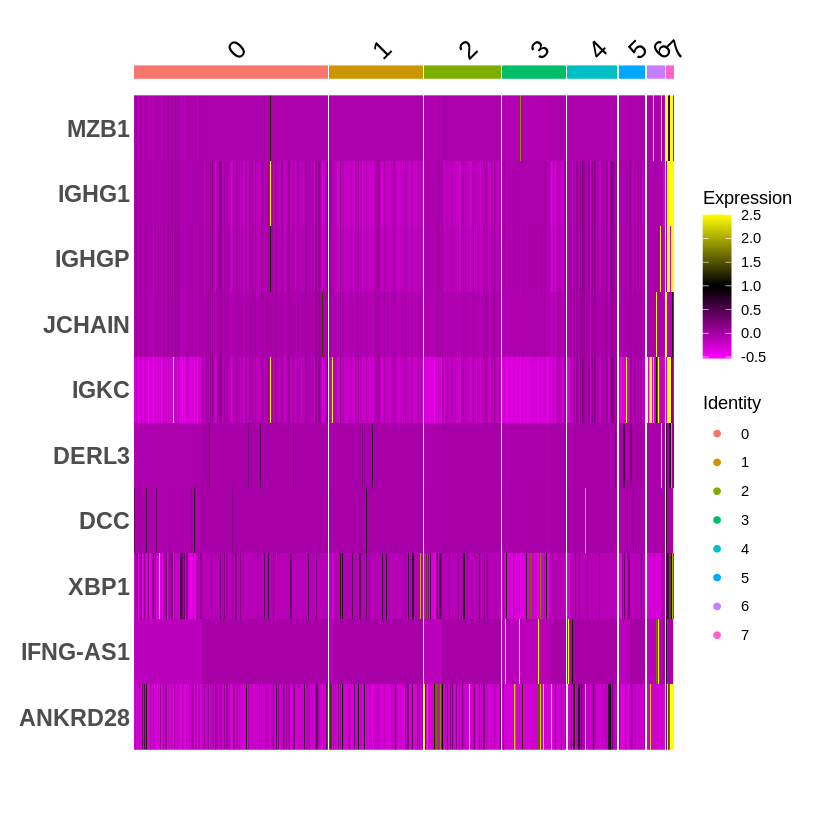

In [22]:
## In this case, we are plotting the top 20 markers Heatmap (or all markers if less than 20) for cluster_7.
# find markers for every cluster compared to all remaining cells, report only the positive ones
obj40.cluster7.markers <- obj40.markers %>% filter(cluster==7) %>% top_n(n = 20, wt = avg_log2FC)
DoHeatmap(obj40, features = as.character(c(obj40.cluster7.markers$gene)), slot = "scale.data") &  theme(axis.text.y = element_text(size = 14, face="bold"))

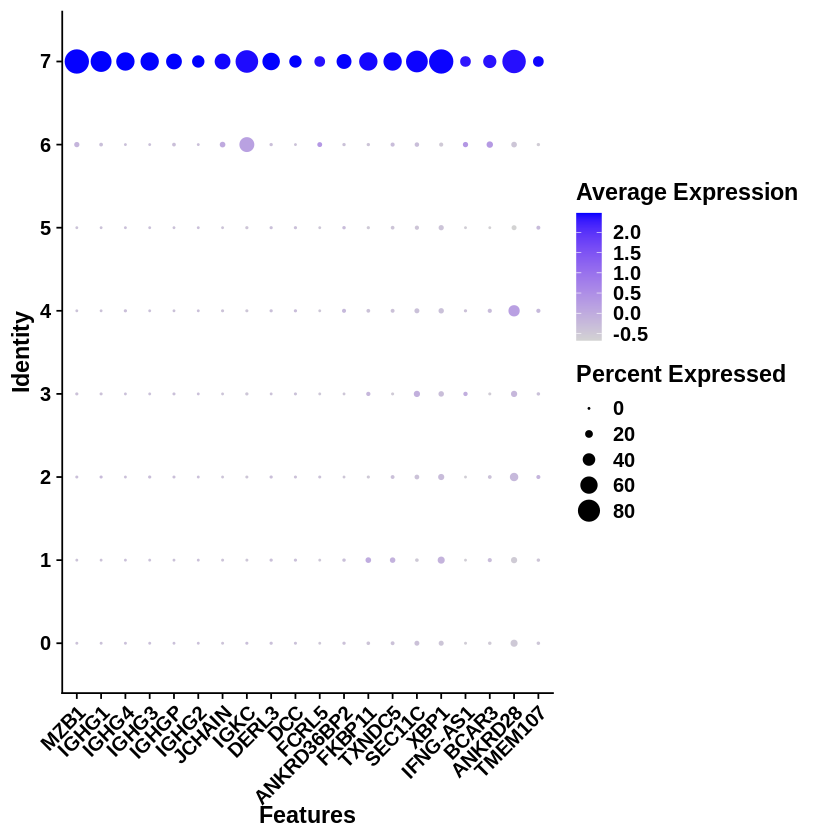

In [23]:
## Dotplot for Cluster_7
obj40.cluster7.markers$gene %>% write.table("obj40.cluster7.csv", row.names = FALSE)
# Dot plots - the size of the dot corresponds to the percentage of cells expressing the feature
# in each cluster. The color represents the average expression level
DotPlot(obj40, features = c(obj40.cluster7.markers$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))


## Aggregated average gene expression across clusters for the top 3 marker genes together plotted as heatmap

In [24]:
DefaultAssay(obj40) <- "RNA"
obj40 <- NormalizeData(obj40)
obj40.averages <- Seurat::AverageExpression(obj40, return.seurat=TRUE, assays = "RNA", layer = "data")

Normalizing layer: counts

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
First group.by variable `ident` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.
Centering and scaling data matrix



In [25]:
top_3_genes <- obj40.markers %>% group_by(cluster) %>% top_n(n = 3, wt = avg_log2FC)
top_3_genes

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
2.367072e-98,3.935531,0.411,0.030,4.643722e-94,0,CALML5
1.127403e-70,3.424133,0.371,0.053,2.211740e-66,0,KRT6A
4.218057e-66,3.801264,0.332,0.041,8.274984e-62,0,KRT14
1.045085e-279,8.995782,0.760,0.008,2.050249e-275,1,COL3A1
9.401689e-154,9.125191,0.435,0.003,1.844423e-149,1,POSTN
6.465251e-127,8.992126,0.365,0.003,1.268353e-122,1,SFRP2
3.058850e-277,8.854426,0.743,0.006,6.000851e-273,2,C1QA
1.086072e-273,9.380992,0.729,0.004,2.130656e-269,2,C1QB
1.362672e-119,8.741417,0.327,0.001,2.673289e-115,2,MS4A4A


Warning message:
“Removed 24 rows containing missing values or values outside the scale range
(`geom_point()`).”


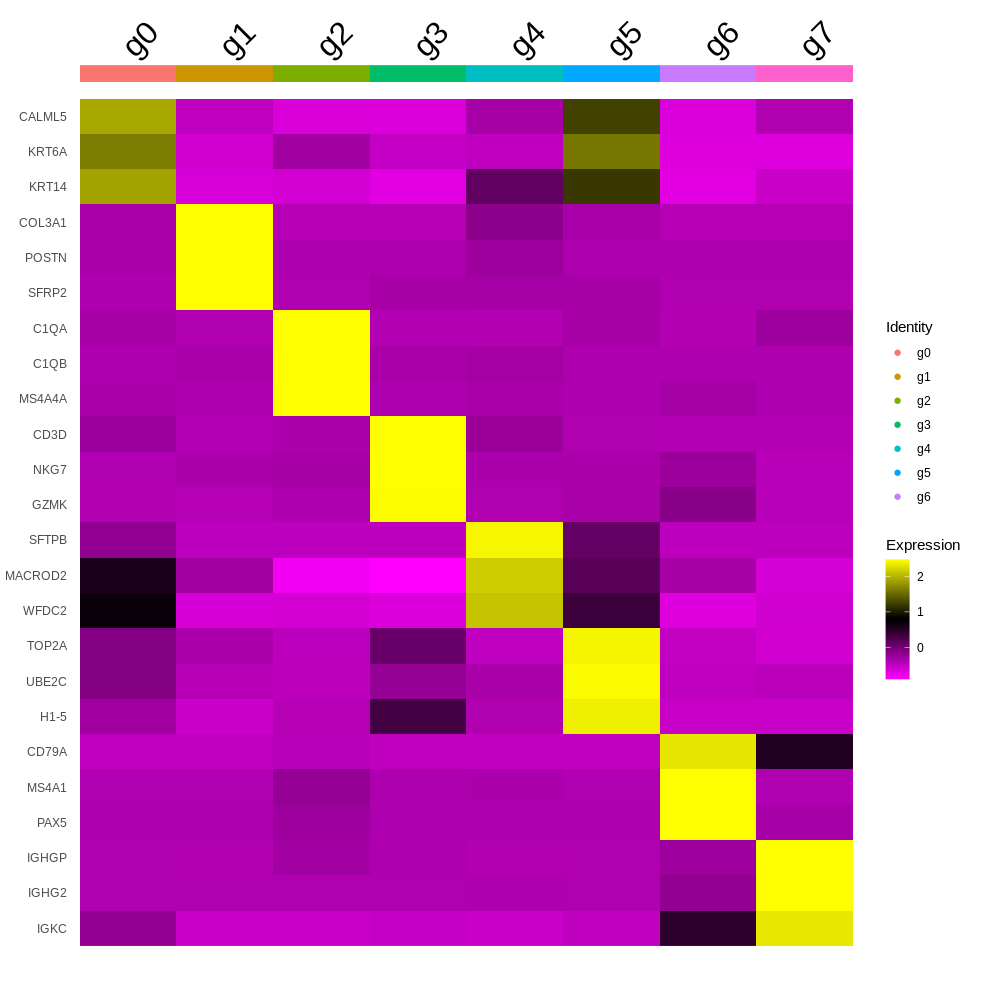

In [26]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 100)
DoHeatmap(obj40.averages, features = as.character(c(top_3_genes$gene)), slot = "scale.data", draw.lines = FALSE, size = 8)

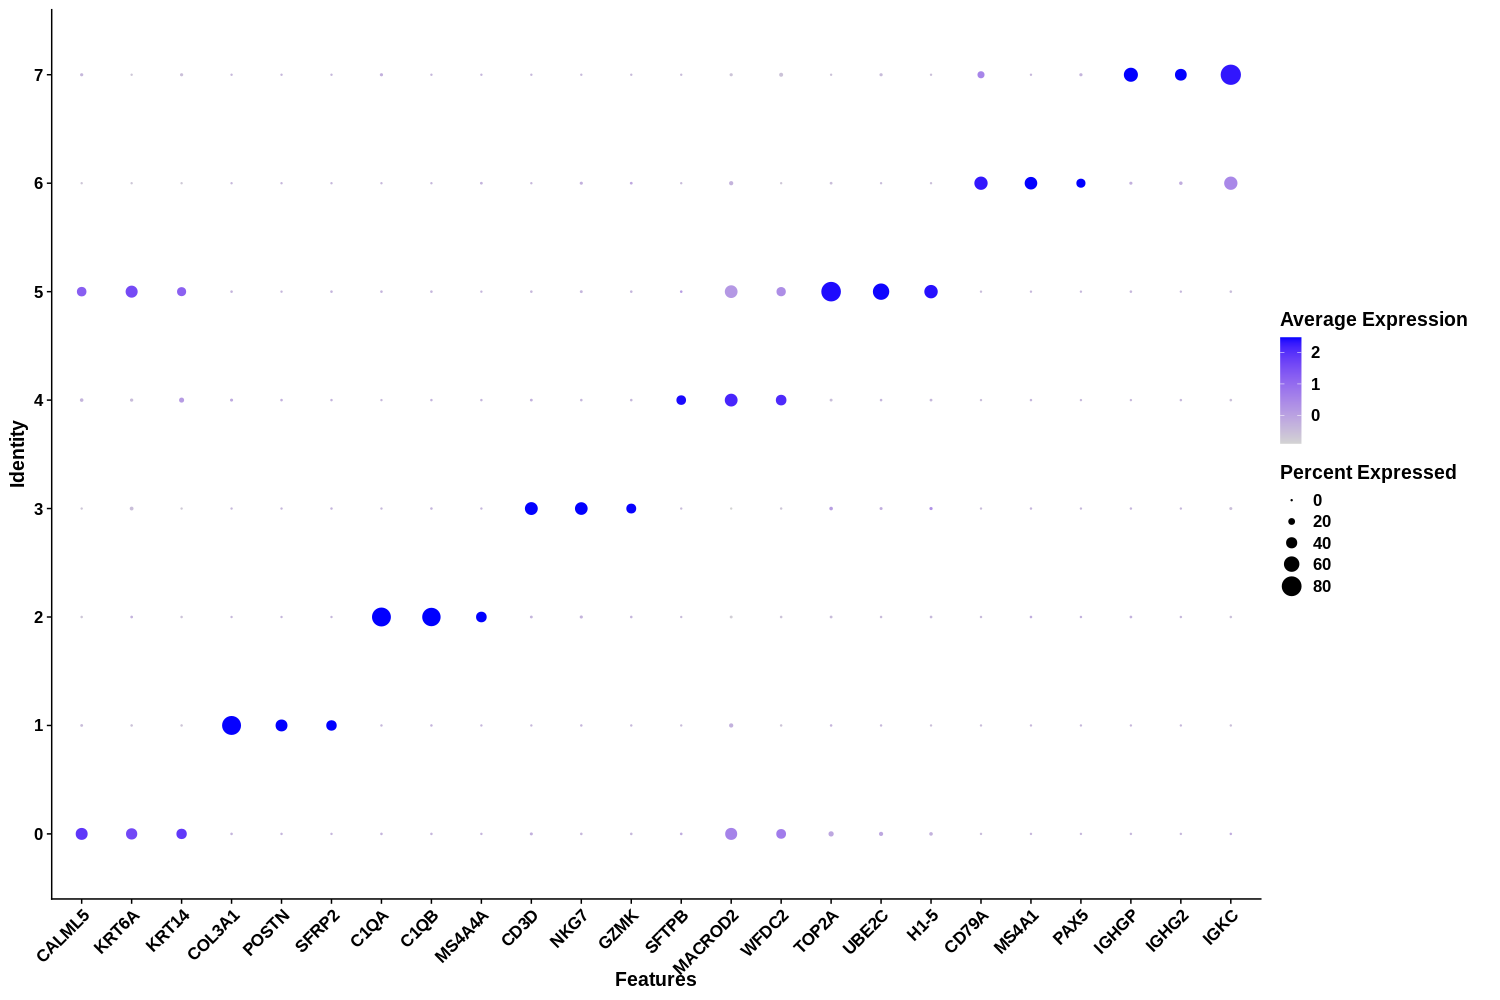

In [27]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
DotPlot(obj40, features = c(top_3_genes$gene)) + RotatedAxis() &  theme(text = element_text(size = 14, face="bold"))

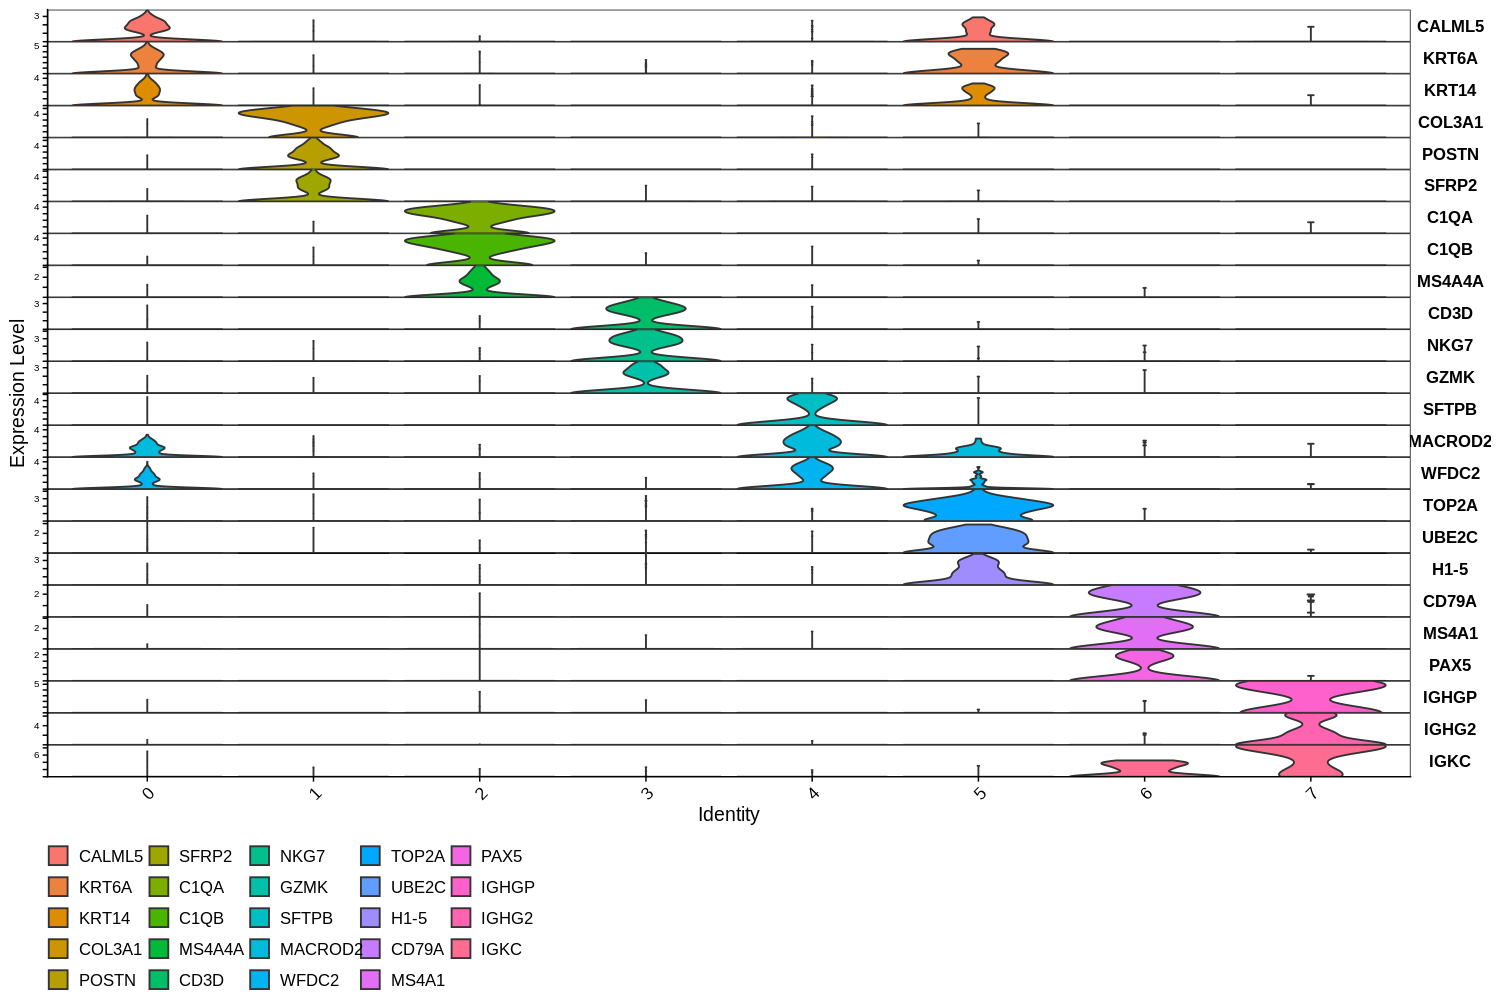

In [28]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
VlnPlot(obj40, features = c(top_3_genes$gene), layer = 'data', group.by = "seurat_clusters", pt.size = 0, stack = TRUE, flip = TRUE) + theme(legend.position = 'bottom')

In [29]:
#`devtools::install_github("satijalab/AzimuthAPI")

In [30]:
library(AzimuthAPI)

In [31]:
obj40 <- CloudAzimuth(obj40)

Running Pan-Human Azimuth on the cloud!

Uploading dataset



Uploading file and listening for updates...
File successfully uploaded 
Running ANNotate function...Running Pan-Human Azimuth: 
 
Reference model and parameters: 
Model name: M0.2 
Evaluation batch size: 40960 
Extract embeddings: True 
Run umap: False 
Refine labels in postprocessing: True 
Integer counts detected by panhumanpy.ANNotate : False 
Log-normalization performed by panhumanpy.ANNotate: False 
Query object: 
Total number of cells: 1868 
Total number of features: 4273 
Overlap w. feature reference: 4273 (~84%) 
 
Splitting query data into 1 evaluation batches. 
 
Running model: 
 
 1/59 ━━━━━━━━━━━━━━━━━━━━ 35s 604ms/step 
 9/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step    
18/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
27/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
37/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
47/

In [32]:
obj40@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,nCount_SCT,nFeature_SCT,sample,integrated_snn_res.0.4,seurat_clusters,silhouette_score,full_hierarchical_labels,final_level_labels,final_level_confidence,full_consistent_hierarchy,azimuth_broad,azimuth_medium,azimuth_fine,azimuth_label
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<fct>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<chr>
AAACCCAAGTACAACA-1,1,21368.5062,5563,5.2828563,15.695680,3466,1633,preT,0,0,0.092996424,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.2265694,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell
AAACCCACATCCGGCA-1,1,2185.0301,1247,4.4332051,15.481174,4023,1233,preT,6,6,0.276890213,Immune cell|Lymphoid cell|B cell|Memory B cell,Memory B cell,0.9669233,TRUE,Immune cell,B cell,Memory B cell,Memory B cell
AAACGAACAGGTGTGA-1,1,908.4158,597,5.4038361,22.289339,3441,660,preT,3,3,0.469265422,Immune cell|Lymphoid cell|T/NK cell|T cell|CD8 T cell|Memory CD8 T cell,Memory CD8 T cell,0.9824817,TRUE,Immune cell,T cell,GZMK CD8 T cell,Memory CD8 T cell
AAACGAAGTTCGTTCC-1,1,1209.6016,803,1.7431788,16.287654,3658,830,preT,3,3,0.297718122,Immune cell|Lymphoid cell|T/NK cell|T cell|CD4 T cell|Memory CD4 T cell,Memory CD4 T cell,0.9350349,TRUE,Immune cell,T cell,Memory CD4 T cell,Memory CD4 T cell
AAAGAACTCCCATGGG-1,1,11959.1598,4019,5.6813659,16.286612,3585,1671,preT,0,0,-0.088038628,Epithelial cell,Epithelial cell,0.5487036,FALSE,False,False,False,Epithelial cell
AAAGAACTCGGTGTAT-1,1,1406.5290,790,3.5262480,28.195370,3654,790,preT,3,3,0.289982962,Immune cell|Lymphoid cell|T/NK cell|T cell|CD4 T cell|Naive CD4 T cell,Naive CD4 T cell,0.4699603,FALSE,False,False,False,Naive CD4 T cell
AAAGGATCAAGTGGTG-1,1,10456.9103,3467,4.5589630,22.770045,3502,1418,preT,0,0,0.022799112,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.3455527,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell
AAAGGGCAGTGCAACG-1,1,22611.9056,5912,6.2437669,16.037617,3543,1765,preT,0,0,0.054652965,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.3826939,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell
AAAGGTAAGTTGCGCC-1,1,15341.5871,4030,6.9310925,25.275847,3883,1665,preT,0,0,0.095814736,Epithelial cell|Epithelial cell of lung|Airway basal cell,Airway basal cell,0.2583768,TRUE,Epithelial cell,Epithelial cell of lung,Airway basal cell,Airway basal cell


In [33]:
# remove cells with low scores
obj40_qc <- subset(obj40, final_level_confidence > 0.5)

In [34]:
# Use azimuth_embed as input Output a UMAP stored in azimuth_umap
obj40_qc <- RunUMAP(obj40_qc, dims = 1:128, reduction = "azimuth_embed", reduction.name = "azimuth_umap")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
18:41:11 UMAP embedding parameters a = 0.9922 b = 1.112

18:41:11 Read 1044 rows and found 128 numeric columns

18:41:11 Using Annoy for neighbor search, n_neighbors = 30

18:41:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:41:11 Writing NN index file to temp file /tmp/Rtmp62PSen/file15576337491d

18:41:11 Searching Annoy index using 1 thread, search_k = 3000

18:41:12 Annoy recall = 100%

18:41:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors 

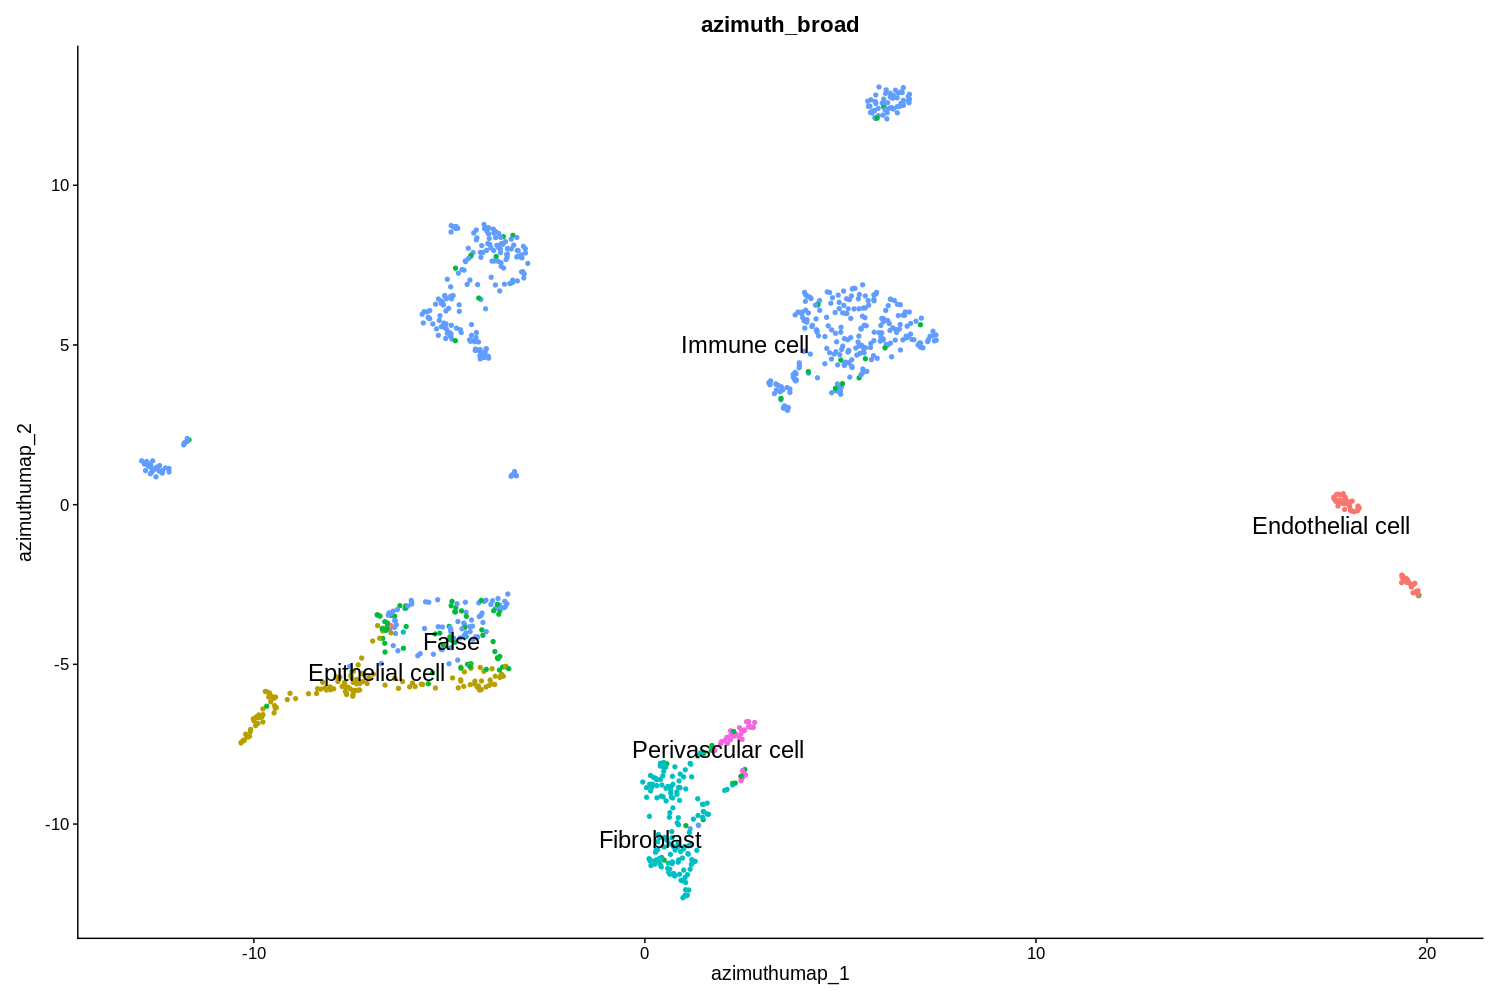

In [35]:
p_az_brd <- DimPlot(obj40_qc, group.by = "azimuth_broad", label.size = 6, label = T, reduction = "azimuth_umap",
    repel = TRUE) + NoLegend()
p_az_brd

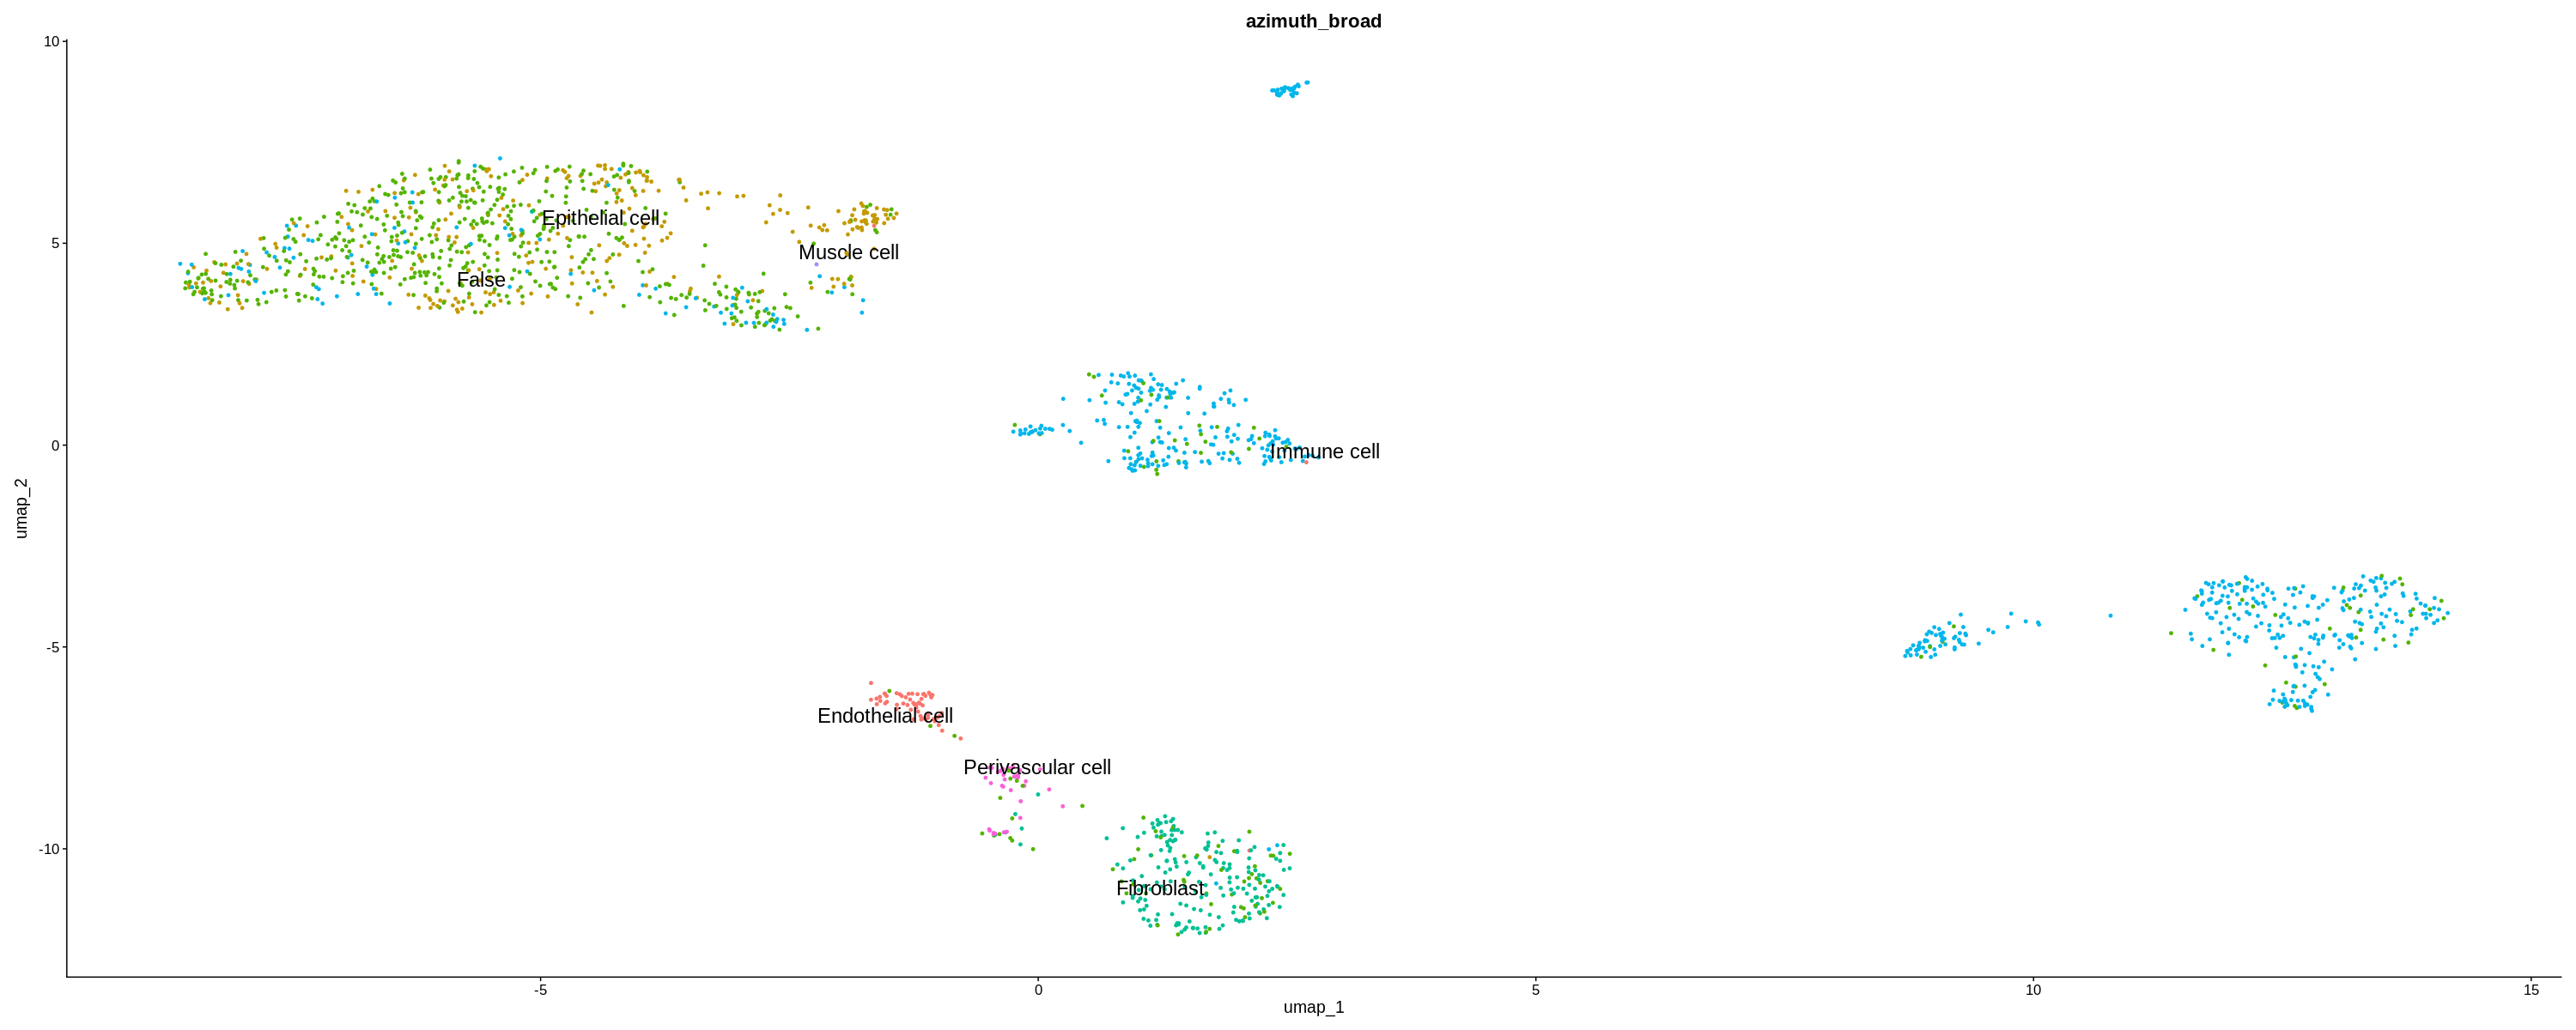

In [67]:
p_az_brd <- DimPlot(obj40, group.by = "azimuth_broad", label.size = 6, label = T, reduction = "umap",
    repel = TRUE) + NoLegend()
p_az_brd

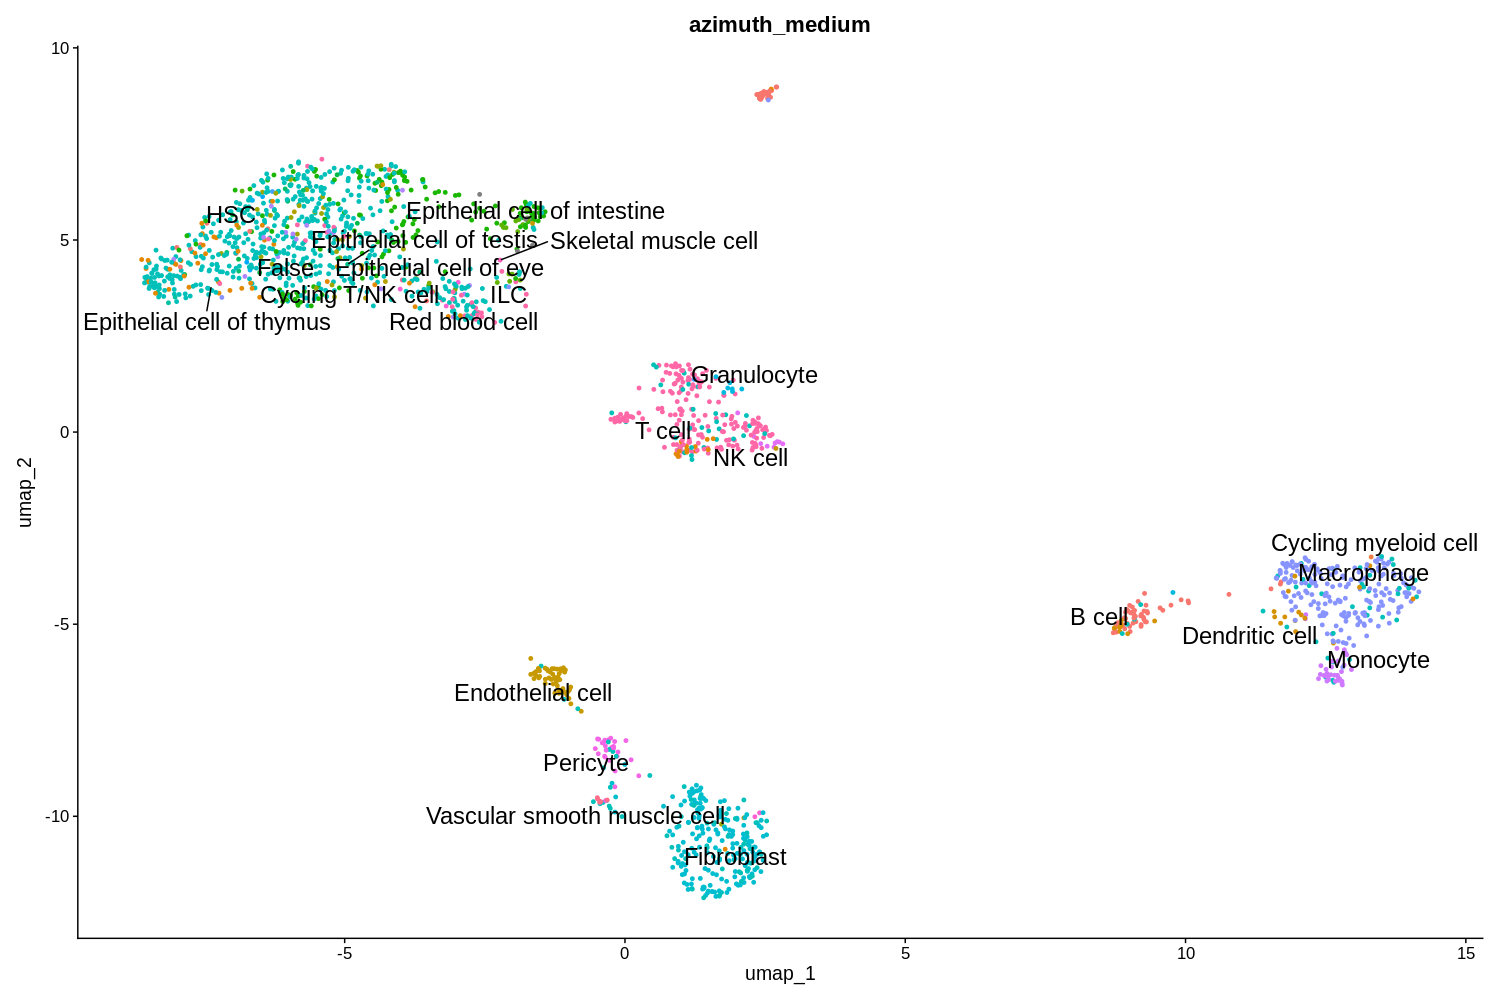

In [60]:
p_az_med <- DimPlot(obj40, group.by = "azimuth_medium", label.size = 6, label = T, reduction = "umap",
    repel = TRUE) + NoLegend()
p_az_med

In [38]:
install.packages("HGNChelper")

Installing package into ‘/content/library’
(as ‘lib’ is unspecified)

also installing the dependency ‘splitstackshape’




In [42]:
install.packages("openxlsx", dependencies = TRUE)

Installing package into ‘/content/library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘operator.tools’, ‘formula.tools’




In [39]:
# load libraries
lapply(c("dplyr","Seurat","HGNChelper"), library, character.only = T)

Please cite our software :) 
 
 Sehyun Oh et al. HGNChelper: identification and correction of invalid gene symbols for human and mouse. F1000Research 2020, 9:1493. DOI: https://doi.org/10.12688/f1000research.28033.1 
 
 Type `citation('HGNChelper')` for a BibTeX entry.



[[1]]
 [1] "AzimuthAPI"   "ggplot2"      "patchwork"    "Seurat"       "SeuratObject"
 [6] "sp"           "dplyr"        "stats"        "graphics"     "grDevices"   
[11] "utils"        "datasets"     "methods"      "base"        

[[2]]
 [1] "AzimuthAPI"   "ggplot2"      "patchwork"    "Seurat"       "SeuratObject"
 [6] "sp"           "dplyr"        "stats"        "graphics"     "grDevices"   
[11] "utils"        "datasets"     "methods"      "base"        

[[3]]
 [1] "HGNChelper"   "AzimuthAPI"   "ggplot2"      "patchwork"    "Seurat"      
 [6] "SeuratObject" "sp"           "dplyr"        "stats"        "graphics"    
[11] "grDevices"    "utils"        "datasets"     "methods"      "base"

## Cell type assignment

Now, let's automatically assign cell types using ScType. For that, we first load 2 additional ScType functions:

In [40]:
# load gene set preparation function
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/gene_sets_prepare.R")
# load cell type annotation function
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/sctype_score_.R")

Next, let's prepare gene sets from the input cell marker file. By default, we use our in-built cell marker DB, however, feel free to use your own data. Just prepare an input XLSX file in the same format as our DB file. DB file should contain four columns (tissueType - tissue type, cellName - cell type, geneSymbolmore1 - positive marker genes, geneSymbolmore2 - marker genes not expected to be expressed by a cell type)

In addition, provide a tissue type your data belongs to:


In [43]:
# DB file
db_ <- "https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/ScTypeDB_full.xlsx";
tissue <- "Immune system" # e.g. Immune system,Pancreas,Liver,Eye,Kidney,Brain,Lung,Adrenal,Heart,Intestine,Muscle,Placenta,Spleen,Stomach,Thymus

# prepare gene sets
gs_list <- gene_sets_prepare(db_, tissue)

Warning message in checkGeneSymbols(markers_all):
“Human gene symbols should be all upper-case except for the 'orf' in open reading frames. The case of some letters was corrected.”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in checkGeneSymbols(markers_all):
“x contains non-approved gene symbols”
Warning message in

In [51]:
obj40 <- ScaleData(obj40)

Centering and scaling data matrix



In [52]:
# check Seurat object version (scRNA-seq matrix extracted differently in Seurat v4/v5)
seurat_package_v5 <- isFALSE('counts' %in% names(attributes(obj40[["RNA"]])));
print(sprintf("Seurat object %s is used", ifelse(seurat_package_v5, "v5", "v4")))

# extract scaled scRNA-seq matrix
scRNAseqData_scaled <- if (seurat_package_v5) as.matrix(obj40[["RNA"]]$scale.data) else as.matrix(obj40[["RNA"]]@scale.data)

# run ScType
es.max <- sctype_score(scRNAseqData = scRNAseqData_scaled, scaled = TRUE, gs = gs_list$gs_positive, gs2 = gs_list$gs_negative)

# NOTE: scRNAseqData parameter should correspond to your input scRNA-seq matrix. For raw (unscaled) count matrix set scaled = FALSE
# When using Seurat, we use "RNA" slot with 'scale.data' by default. Please change "RNA" to "SCT" for sctransform-normalized data,
# or to "integrated" for joint dataset analysis. To apply sctype with unscaled data, use e.g. obj40[["RNA"]]$counts or obj40[["RNA"]]@counts, with scaled set to FALSE.

# merge by cluster
cL_resutls <- do.call("rbind", lapply(unique(obj40@meta.data$seurat_clusters), function(cl){
    es.max.cl = sort(rowSums(es.max[ ,rownames(obj40@meta.data[obj40@meta.data$seurat_clusters==cl, ])]), decreasing = !0)
    head(data.frame(cluster = cl, type = names(es.max.cl), scores = es.max.cl, ncells = sum(obj40@meta.data$seurat_clusters==cl)), 10)
}))
sctype_scores <- cL_resutls %>% group_by(cluster) %>% top_n(n = 1, wt = scores)

# set low-confident (low ScType score) clusters to "unknown"
sctype_scores$type[as.numeric(as.character(sctype_scores$scores)) < sctype_scores$ncells/4] <- "Unknown"
print(sctype_scores[,1:3])

[1] "Seurat object v5 is used"
# A tibble: 8 × 3
# Groups:   cluster [8]
  cluster type                scores
  <fct>   <chr>                <dbl>
1 0       Cancer cells         464. 
2 6       Naive B cells        219. 
3 3       Memory CD8+ T cells  766. 
4 7       Plasma B cells       138. 
5 5       Cancer cells          75.7
6 2       Macrophages         1071. 
7 4       Unknown               24.1
8 1       Endothelial          339. 


Please note that sctype_score function (used above) accepts both positive and negative markers through gs and gs2 arguments. In case, there are no negative markers (i.e. markers providing evidence against a cell being of specific cell type) just set gs2 argument to NULL (i.e. gs2 = NULL).

We can also overlay the identified cell types on UMAP plot:

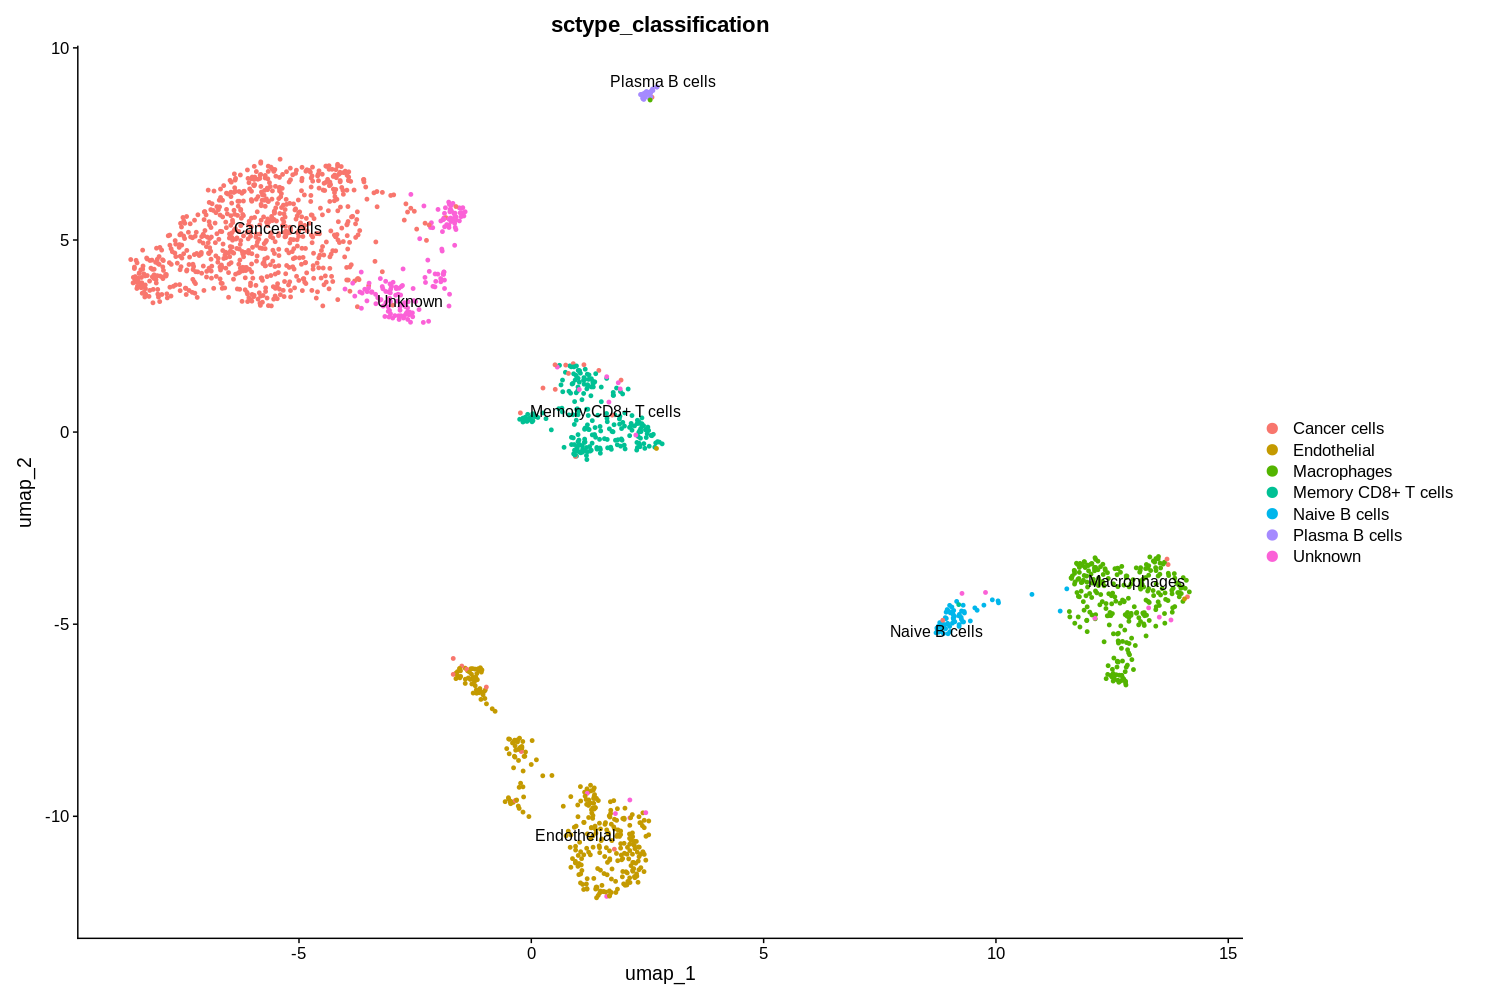

In [61]:
obj40@meta.data$sctype_classification = ""
for(j in unique(sctype_scores$cluster)){
  cl_type = sctype_scores[sctype_scores$cluster==j,];
  obj40@meta.data$sctype_classification[obj40@meta.data$seurat_clusters == j] = as.character(cl_type$type[1])
}

p_sc <- DimPlot(obj40, reduction = "umap", label = TRUE, repel = TRUE, group.by = 'sctype_classification')
p_sc


# Now lets combine all both annotations together and see what makes sense

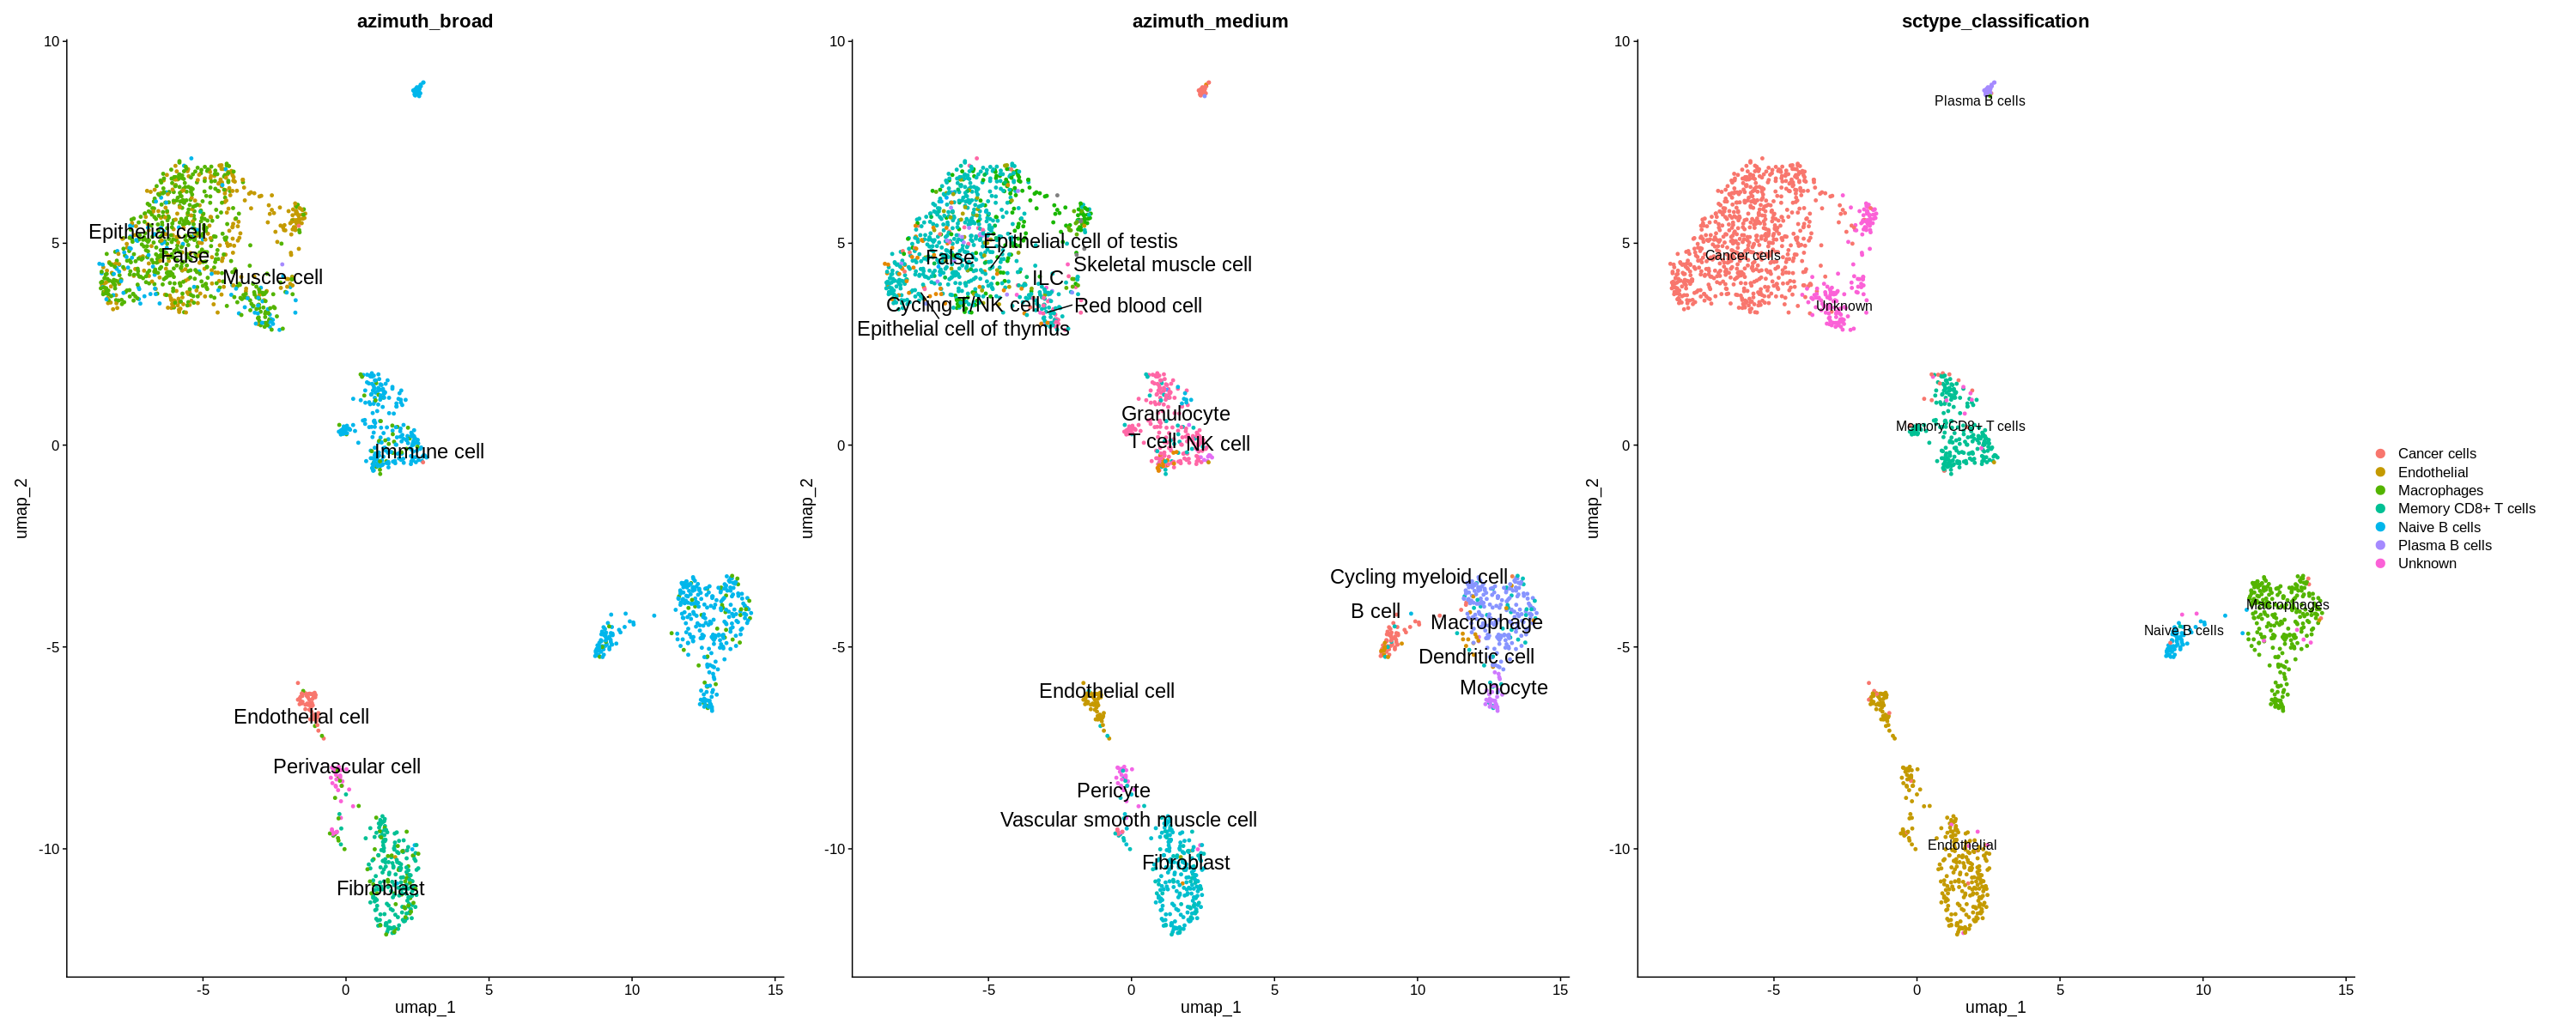

In [68]:
options(repr.plot.width = 30, repr.plot.height = 12, repr.plot.res = 100)
p_az_brd + p_az_med + p_sc

## Cell count by Sample

In [99]:
library(reshape2)

In [71]:
table(obj40$sample)


postT  preT 
 1271   597 

## Cell count by cluster

In [91]:
table(obj40$sctype_classification)


       Cancer cells         Endothelial         Macrophages Memory CD8+ T cells 
                779                 329                 269                 225 
      Naive B cells      Plasma B cells             Unknown 
                 62                  28                 176 

In [92]:
table(obj40$sctype_classification, obj40@meta.data$sample)

                     
                      postT preT
  Cancer cells          497  282
  Endothelial           316   13
  Macrophages           207   62
  Memory CD8+ T cells    56  169
  Naive B cells           9   53
  Plasma B cells         23    5
  Unknown               163   13

## Count of cells per cluster

In [95]:
table_count <- table(obj40$sctype_classification, obj40@meta.data$sample)
table_count <- as.data.frame.matrix(table_count)
table_count

,postT,preT
,<int>,<int>
Cancer cells,497,282
Endothelial,316,13
Macrophages,207,62
Memory CD8+ T cells,56,169
Naive B cells,9,53
Plasma B cells,23,5
Unknown,163,13


## Normalzied count of cells per cluster

In [96]:
apply(table_count, 2, function(x) {as.integer((x/sum(x))*10000)})

postT,preT
3910,4723
2486,217
1628,1038
440,2830
70,887
180,83
1282,217


## Plotting the normalized cell counts

In [100]:
table_count_rel <- as.data.frame(apply(table_count, 2, function(x) {as.integer((x/sum(x))*10000)}))
table_count_rel$clus <- rownames(table_count)
df <- melt(table_count_rel[,c("clus", 'preT', 'postT')], id.vars=1)

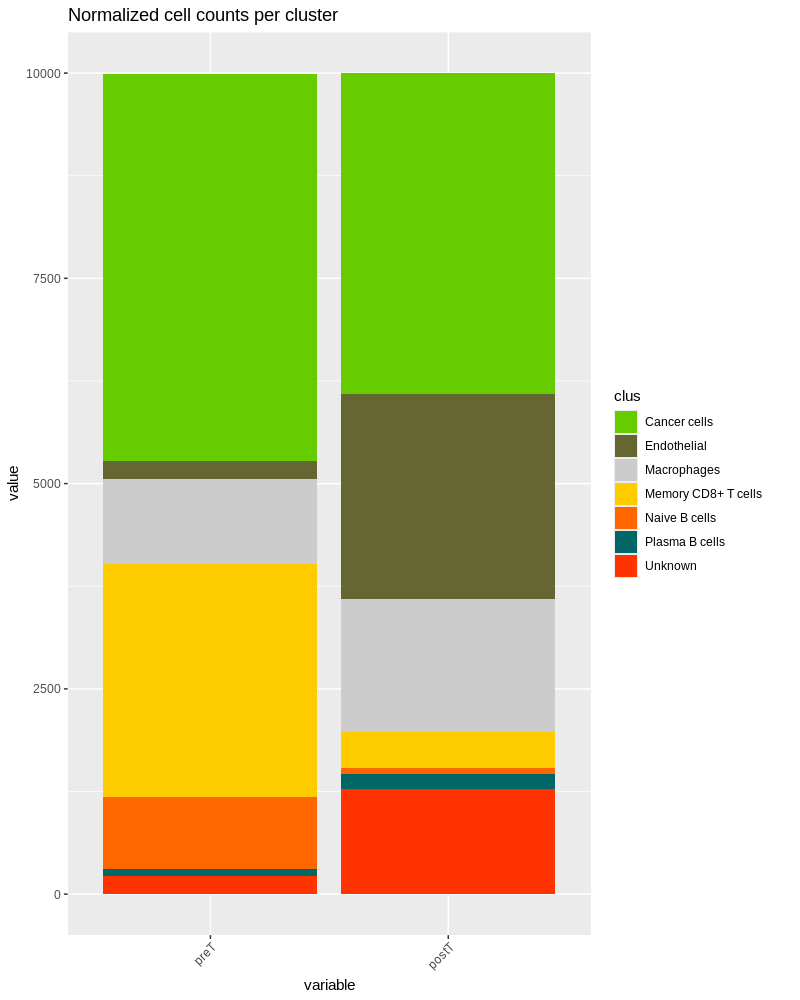

In [101]:
options(repr.plot.width = 8, repr.plot.height = 10, repr.plot.res = 100)
ggplot(df, aes(x = variable, y = value, fill = clus)) +
  geom_bar(position="stack", stat = "identity", width=0.9) +
  scale_fill_manual(values = c("#66CC00","#666633","#CCCCCC", "#FFCC00", "#FF6600", "#006666", "#FF3300", "#CCCC99", "#CC3300", "#0099CC", "#FF3399", "#990066", "#999999", "#006699", "#3399FF", "#99CCFF", "#FFFF00", "#330099", "#660066", "#FFCC66", "#FF9966", "#C5D8F3", "#7ECDBB", "#A6A6A6", "#E6916C", "#CDB7D2","#FBEFAB")) +
  ggtitle("Normalized cell counts per cluster") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [37]:
sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] AzimuthAPI_0.2.0   ggplot2_4.0.3      patchwork_1.3.2    Seurat_5.5.1      
[5] SeuratObject_5.4.0 sp_2.2-1           dplyr_1.2.1       

loaded via a namespace (and not attac